In [2]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls

Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 719, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 719 (delta 92), reused 74 (delta 40), pack-reused 586 (from 1)
Receiving objects: 100% (719/719), 799.17 KiB | 3.32 MiB/s, done.
Resolving deltas: 100% (370/370), done.
/content/NuOscProbExact/src
globaldefs.py  hamiltonians2nu.py  hamiltonians3nu.py  oscprob2nu.py  oscprob3nu.py


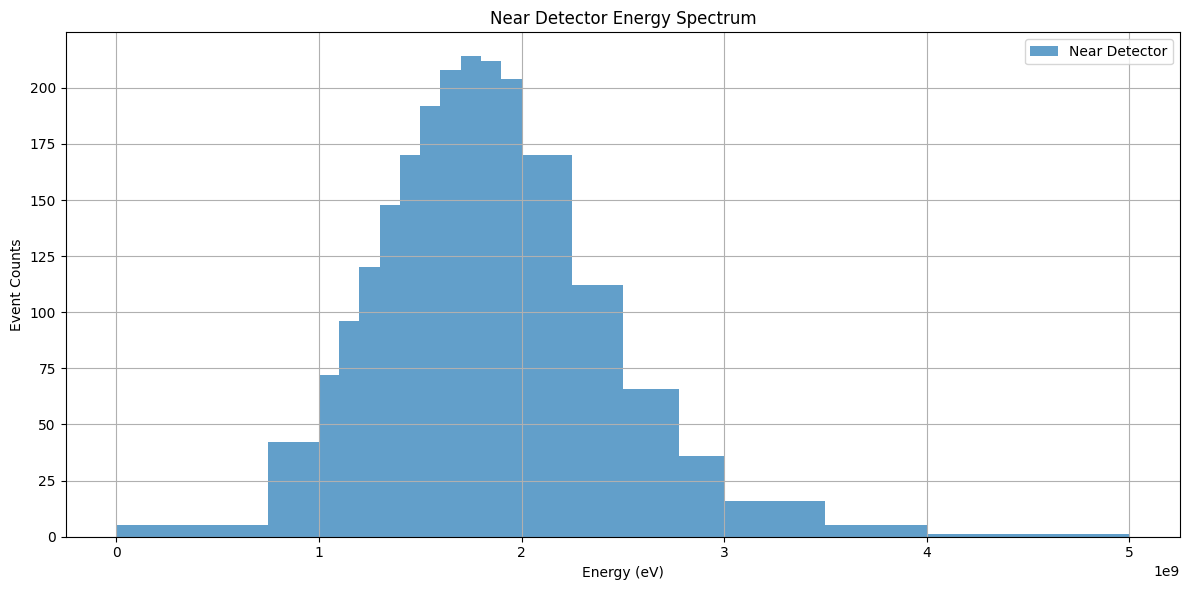

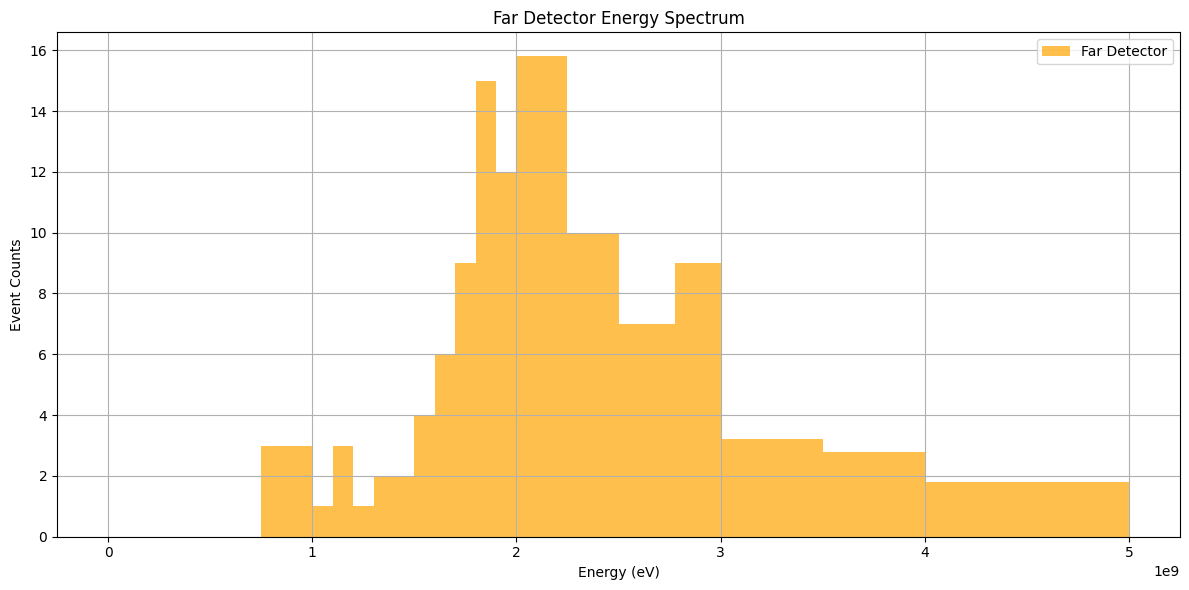

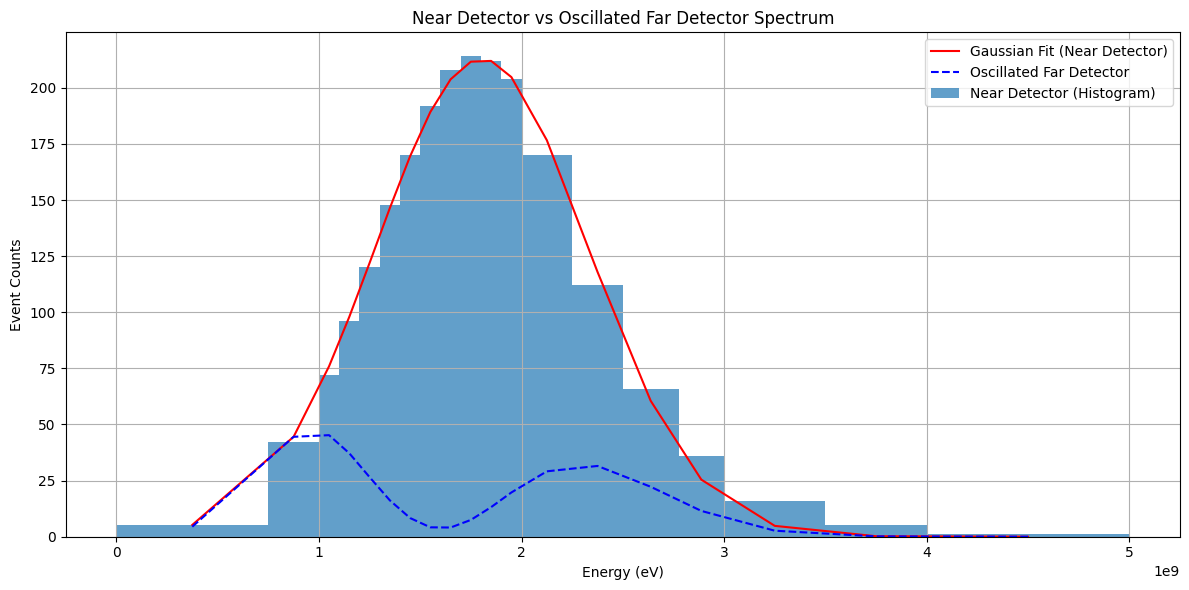

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from NuOscProbExact.src.oscprob3nu import probabilities_3nu
from NuOscProbExact.src.hamiltonians3nu import hamiltonian_3nu_vacuum_energy_independent, hamiltonian_3nu_matter
from NuOscProbExact.src.globaldefs import *

# Given Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Initialize the vacuum Hamiltonian
h_vacuum_energy_indep = hamiltonian_3nu_vacuum_energy_independent(
    S12_NO_BF, S23_NO_BF, S13_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF
)

# Function to compute oscillation probabilities for muon neutrinos
def compute_probabilities_matter(baseline, energy_values):
    Prob_mu = []
    for E in energy_values:
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        _, _, _, _, Pmm, _, _, _, _ = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_mu.append(Pmm)
    return np.array(Prob_mu)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

# Compute oscillation probabilities for the far detector
Prob_mu_far = compute_probabilities_matter(Length_far, bin_centers)

# Oscillated far detector spectrum (apply oscillation to fitted Gaussian)
oscillated_fd = gaussian(bin_centers, *popt_nd) * Prob_mu_far / np.max(Prob_mu_far)

# Plotting Near Detector Histogram
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, counts_nd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Near Detector')
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Far Detector Histogram
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, counts_fd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Far Detector', color='orange')
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Far Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


# Plot Near Detector and Oscillated Far Detector Histograms
plt.figure(figsize=(12, 6))

# Near Detector
plt.bar(
    bin_centers,
    counts_nd,
    width=np.diff(bin_edges),
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers,
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector
plt.plot(
    bin_centers,
    oscillated_fd,
    "b--",
    label="Oscillated Far Detector"
)

# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


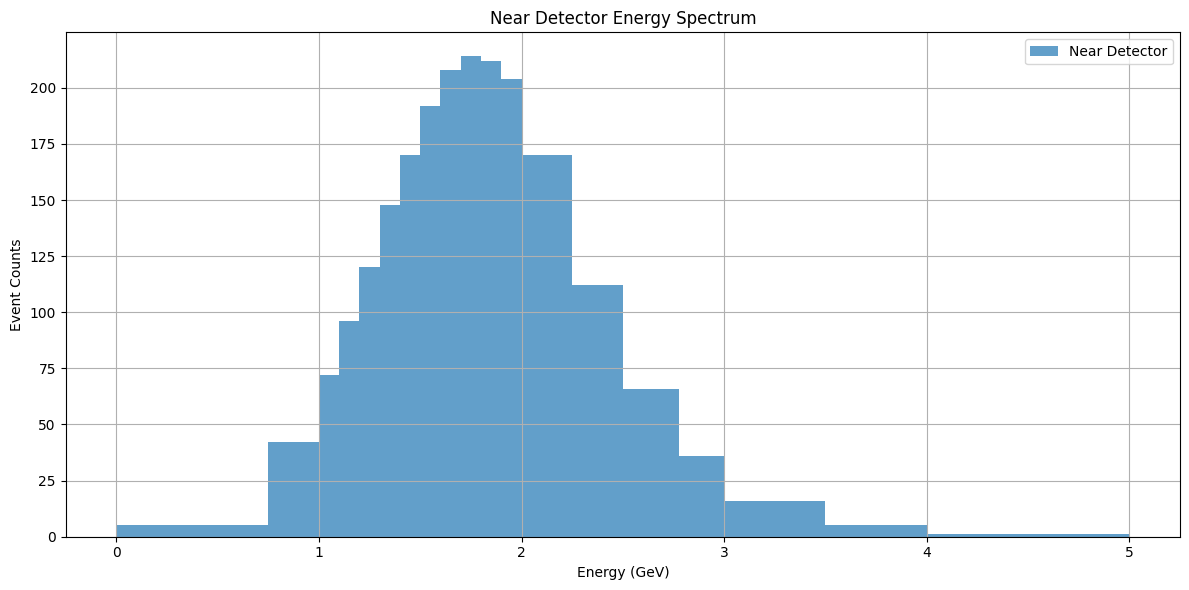

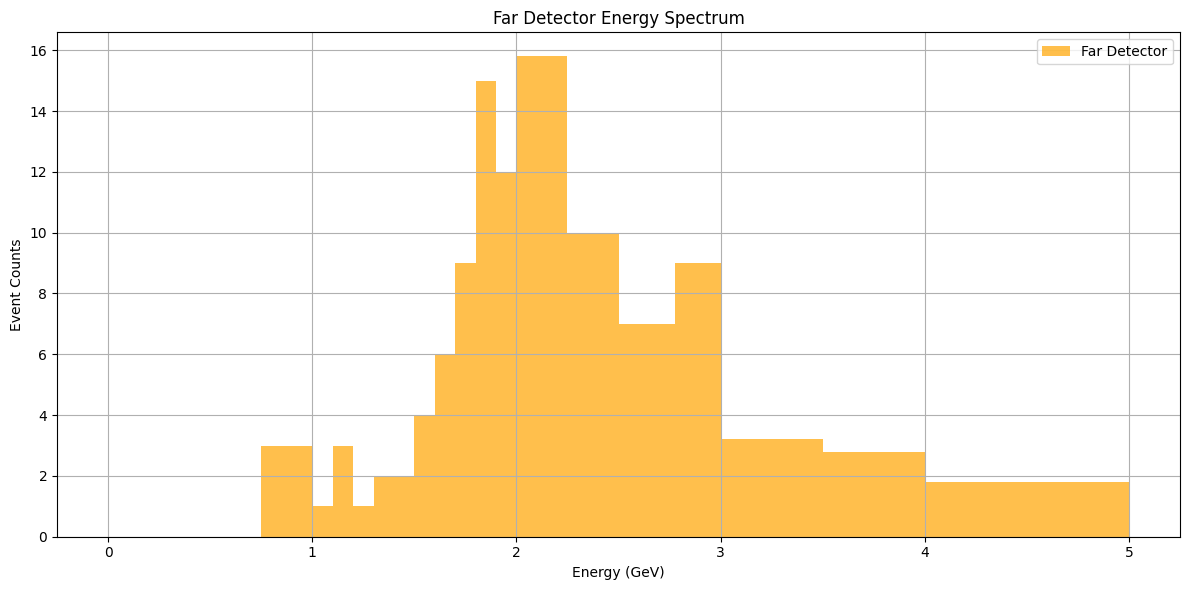

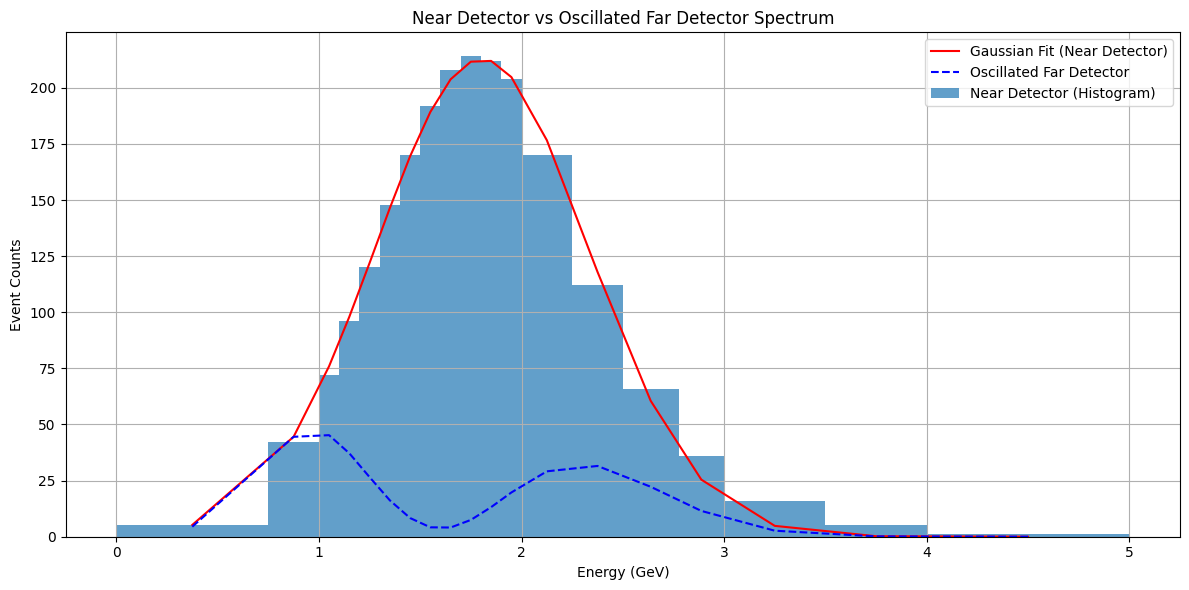

In [4]:


# Rescale bin_centers and bin_edges to GeV
bin_centers_GeV = bin_centers / 1e9  # Convert eV to GeV
bin_edges_GeV = bin_edges / 1e9      # Convert eV to GeV

# Plotting Near Detector Histogram
plt.figure(figsize=(12, 6))
plt.bar(bin_centers_GeV, counts_nd, width=np.diff(bin_edges_GeV), align='center', alpha=0.7, label='Near Detector')
plt.xlabel("Energy (GeV)")  # Changed label to GeV
plt.ylabel("Event Counts")
plt.title("Near Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Far Detector Histogram
plt.figure(figsize=(12, 6))
plt.bar(bin_centers_GeV, counts_fd, width=np.diff(bin_edges_GeV), align='center', alpha=0.7, label='Far Detector', color='orange')
plt.xlabel("Energy (GeV)")  # Changed label to GeV
plt.ylabel("Event Counts")
plt.title("Far Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Plot Near Detector and Oscillated Far Detector Histograms
plt.figure(figsize=(12, 6))

# Near Detector
plt.bar(
    bin_centers_GeV,
    counts_nd,
    width=np.diff(bin_edges_GeV),
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers_GeV,
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector
plt.plot(
    bin_centers_GeV,
    oscillated_fd,
    "b--",
    label="Oscillated Far Detector"
)

# Plot settings
plt.xlabel("Energy (GeV)")  # Changed label to GeV
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


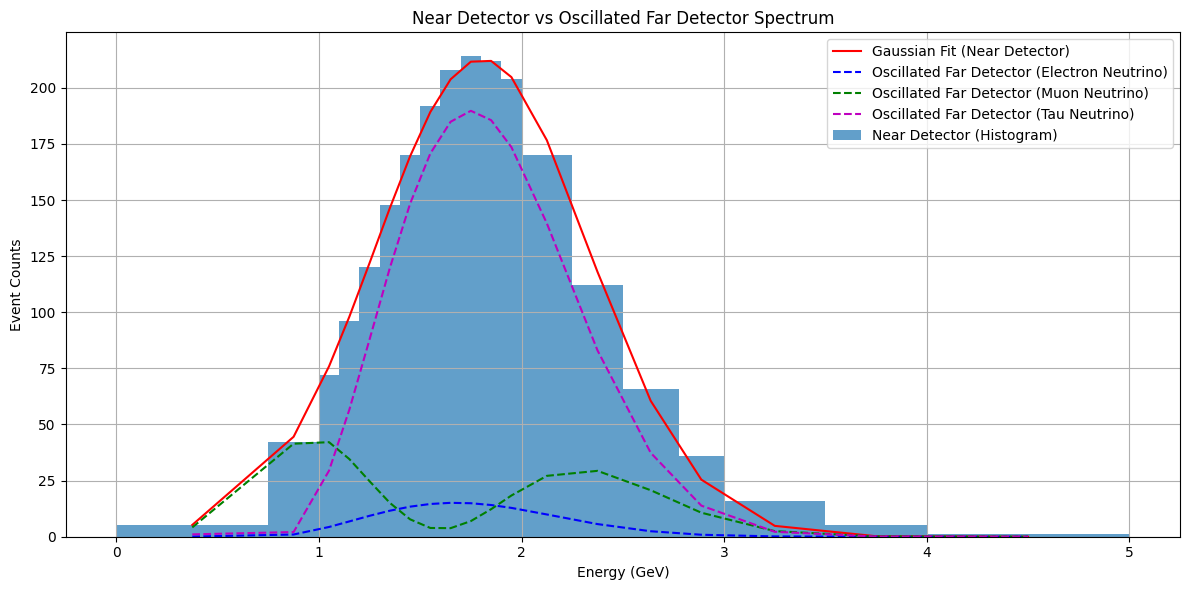

In [5]:
# Rescale bin_centers and bin_edges to GeV
bin_centers_GeV = bin_centers / 1e9  # Convert eV to GeV
bin_edges_GeV = bin_edges / 1e9      # Convert eV to GeV

# Function to compute oscillation probabilities for all three flavors
def compute_probabilities_all_flavors(baseline, energy_values):
    Prob_e, Prob_mu, Prob_tau = [], [], []
    for E in energy_values:
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_e.append(Pme)  # Electron neutrino survival
        Prob_mu.append(Pmm)  # Muon neutrino survival
        Prob_tau.append(Pmt)  # Tau neutrino survival
    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute oscillation probabilities for all flavors at the far detector
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_all_flavors(Length_far, bin_centers)

# Generate oscillated far detector spectra for all flavors
oscillated_fd_e = gaussian(bin_centers, *popt_nd) * Prob_e_far
oscillated_fd_mu = gaussian(bin_centers, *popt_nd) * Prob_mu_far
oscillated_fd_tau = gaussian(bin_centers, *popt_nd) * Prob_tau_far

# Plot Near Detector and Oscillated Far Detector Histograms in GeV
plt.figure(figsize=(12, 6))

# Near Detector
plt.bar(
    bin_centers_GeV,  # Use bin_centers in GeV
    counts_nd,
    width=np.diff(bin_edges_GeV),  # Convert bin width from eV to GeV
    align="center",
    alpha=0.7,
    label="Near Detector (Histogram)"
)
plt.plot(
    bin_centers_GeV,  # Use bin_centers in GeV
    gaussian(bin_centers, *popt_nd),
    "r-",
    label="Gaussian Fit (Near Detector)"
)

# Oscillated Far Detector for all flavors
plt.plot(
    bin_centers_GeV,  # Use bin_centers in GeV
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers_GeV,  # Use bin_centers in GeV
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers_GeV,  # Use bin_centers in GeV
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (GeV)")  # Change the x-axis label to GeV
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



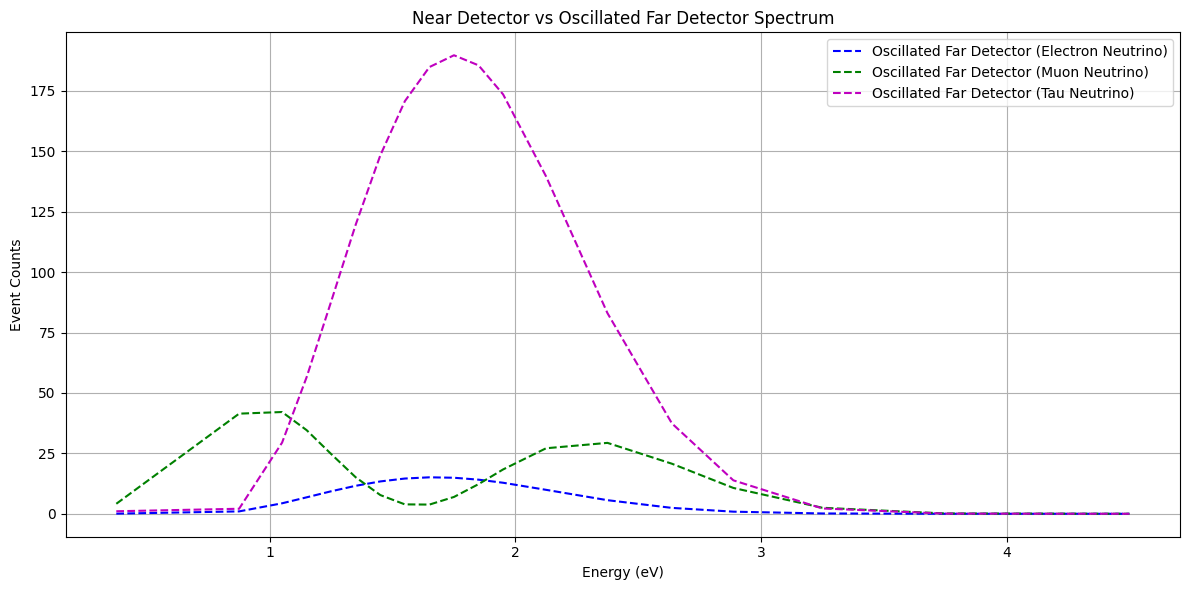

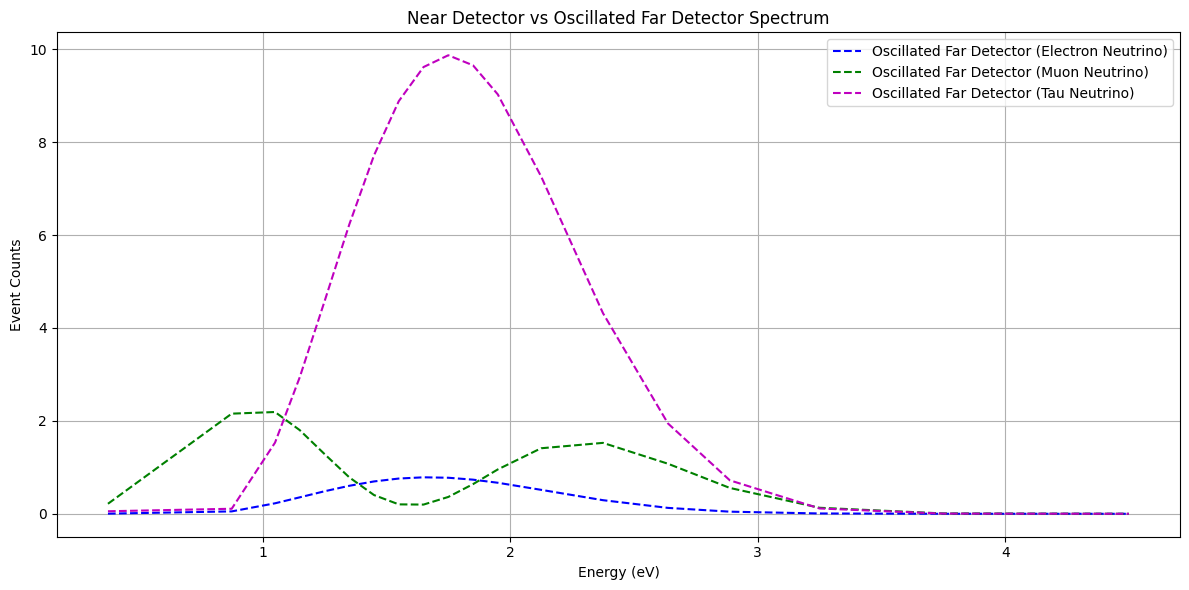

[0.01192236 0.02229554 0.05720859 0.06958791 0.07644371 0.07915168
 0.07902751 0.07709486 0.07408321 0.07048801 0.06663496 0.06273214
 0.05613913 0.04772888 0.04035475 0.03459724 0.02802556 0.02148429
 0.01513107]


In [6]:
# Function to compute oscillation probabilities for all three flavors
def compute_probabilities_all_flavors(baseline, energy_values):
    Prob_e, Prob_mu, Prob_tau = [], [], []
    for E in energy_values:
        h_matter = hamiltonian_3nu_matter(h_vacuum_energy_indep, E, VCC_EARTH_CRUST)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(h_matter, baseline * CONV_KM_TO_INV_EV)
        # Sum contributions for each flavor
        Prob_e.append(Pme)  # Electron neutrino survival
        Prob_mu.append(Pmm)  # Muon neutrino survival
        Prob_tau.append(Pmt)  # Tau neutrino survival
    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute probabilities for all flavors at the far detector
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities_all_flavors(Length_far, bin_centers)

# Generate oscillated far detector spectra for all flavors
nd_gaussian = gaussian(bin_centers, *popt_nd)  # Near detector Gaussian spectrum
oscillated_fd_e = nd_gaussian * Prob_e_far
oscillated_fd_mu = nd_gaussian * Prob_mu_far
oscillated_fd_tau = nd_gaussian * Prob_tau_far




# Plotting Near Detector and Oscillated Far Detector Spectra
plt.figure(figsize=(12, 6))



# Oscillated Far Detector
plt.plot(
    bin_centers_GeV,
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Normalize the far detector spectra to match total event counts
scale_factor_fd = np.sum(counts_fd) / np.sum(nd_gaussian)
oscillated_fd_e *= scale_factor_fd
oscillated_fd_mu *= scale_factor_fd
oscillated_fd_tau *= scale_factor_fd



# Plotting Near Detector and Oscillated Far Detector Spectra
plt.figure(figsize=(12, 6))



# Oscillated Far Detector
plt.plot(
    bin_centers_GeV,
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers_GeV,
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)



# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print(Prob_e_far)




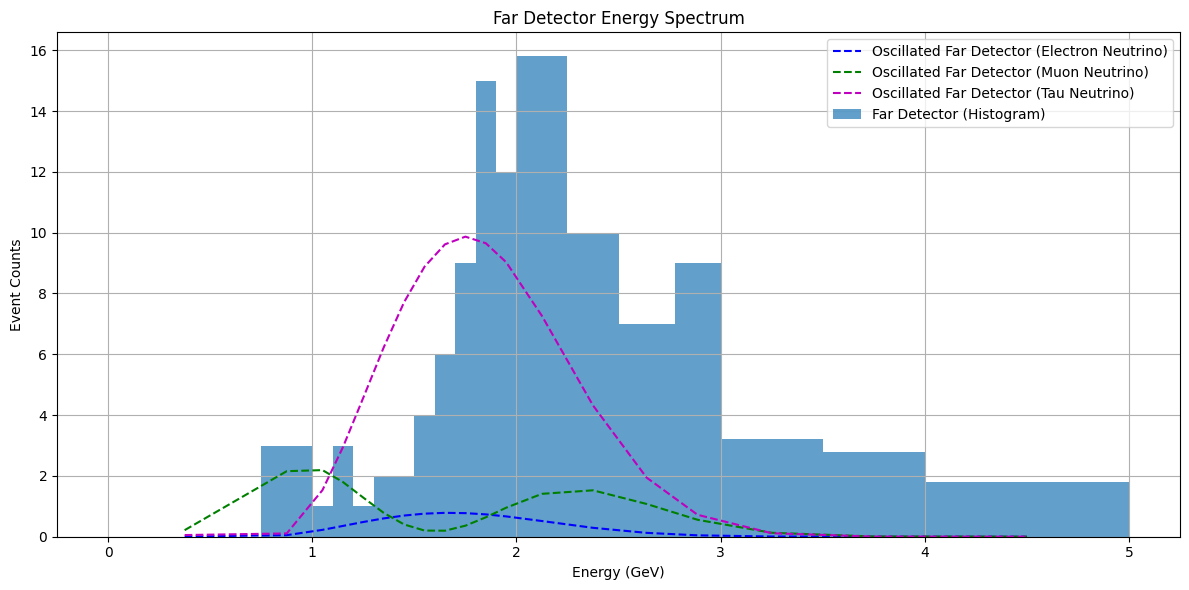

In [7]:
# Plotting Far Detector Histogram in GeV
plt.figure(figsize=(12, 6))

# Plot the histogram in GeV
plt.bar(
    bin_centers_GeV,  # bin_centers converted to GeV
    counts_fd,
    width=np.diff(bin_edges_GeV),  # bin_edges converted to GeV
    align="center",
    alpha=0.7,
    label="Far Detector (Histogram)"  # Changed label to Far Detector
)

# Plot oscillated spectra
plt.plot(
    bin_centers_GeV,  # bin_centers converted to GeV
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers_GeV,  # bin_centers converted to GeV
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers_GeV,  # bin_centers converted to GeV
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)

# Plot settings
plt.xlabel("Energy (GeV)")  # Updated to GeV
plt.ylabel("Event Counts")
plt.title("Far Detector Energy Spectrum")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


4 flavour

In [8]:
def hamiltonian_4nu_vacuum(energy, mixing_matrix, mass_squared_differences):
    H_vacuum = np.zeros((4, 4), dtype=complex)
    for i in range(4):
        for j in range(4):
            H_vacuum[i, j] = mixing_matrix[i, j] * mixing_matrix[j, i].conj() * mass_squared_differences[i]
    H_vacuum *= 1 / (2 * energy)
    return H_vacuum


def hamiltonian_4nu_matter(h_vacuum, energy, vcc):
    V = np.zeros((4, 4), dtype=complex)
    V[0, 0] = vcc  # Only for active neutrinos (electron neutrino)
    return h_vacuum + V

def mixing_matrix_4nu(theta12, theta13, theta23, delta13, theta14, theta24, theta34, delta14, delta24):
    # Build each rotation matrix and combine
    R12 = rotation_matrix(theta12, 1, 2)
    R13 = rotation_matrix(theta13, 1, 3, delta13)
    R23 = rotation_matrix(theta23, 2, 3)
    R14 = rotation_matrix(theta14, 1, 4, delta14)
    R24 = rotation_matrix(theta24, 2, 4, delta24)
    R34 = rotation_matrix(theta34, 3, 4)
    return np.dot(R34, np.dot(R24, np.dot(R14, np.dot(R23, np.dot(R13, R12)))))

def probabilities_4nu(h_matter, baseline):
    evolution_matrix = expm(-1j * h_matter * baseline)
    probabilities = np.abs(evolution_matrix) ** 2
    return probabilities

def compute_probabilities_4nu(baseline, energy_values, mixing_matrix, mass_squared_differences, vcc):
    Prob_e, Prob_mu, Prob_tau, Prob_sterile = [], [], [], []

    for E in energy_values:
        h_vacuum = hamiltonian_4nu_vacuum(E, mixing_matrix, mass_squared_differences)
        h_matter = hamiltonian_4nu_matter(h_vacuum, E, vcc)  # Matter Hamiltonian with potential

        # Calculate oscillation probabilities
        P = probabilities_4nu(h_matter, baseline)

        # Append the survival probabilities for each flavor
        Prob_e.append(P[0, 0])  # Electron neutrino survival
        Prob_mu.append(P[1, 1])  # Muon neutrino survival
        Prob_tau.append(P[2, 2])  # Tau neutrino survival
        Prob_sterile.append(P[3, 3])  # Sterile neutrino survival

    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau), np.array(Prob_sterile)


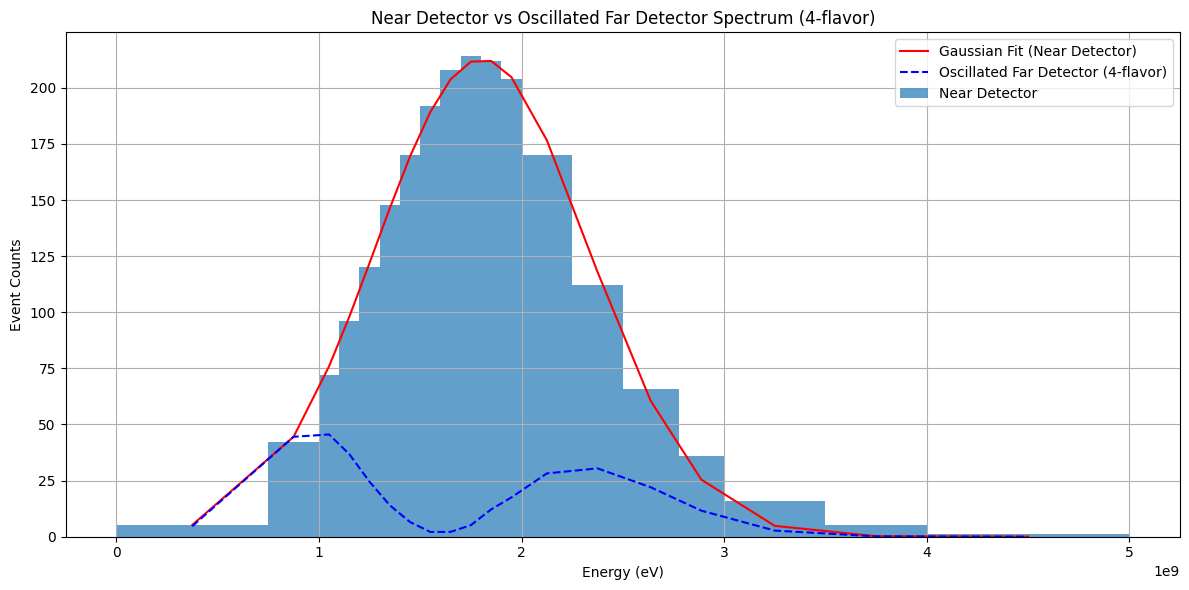

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

# Constants
CONV_KM_TO_INV_EV = 5.067731e9  # Conversion factor from km to inverse eV
VCC_EARTH_CRUST = 7.6e-14  # Matter potential in eV

# Define mixing matrix elements
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

# Define Hamiltonian
def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])  # Mass squared differences
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    H_vacuum = U @ m2_diag @ np.conj(U.T) / (2 * E)
    return H_vacuum

def hamiltonian_4nu_matter(H_vacuum, E, VCC):
    H_matter = H_vacuum + np.diag([VCC, 0, 0, 0])
    return H_matter

# Compute probabilities
def probabilities_4nu(H_matter, baseline):
    H_t = -1j * H_matter * baseline
    S = expm(H_t)  # Evolution operator
    Pmm = np.abs(S[1, 1])**2  # Muon neutrino survival probability
    return Pmm

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Oscillation Parameters
theta12, theta13, theta23 = np.radians([33.82, 8.61, 48.3])  # Standard angles
theta14, theta24, theta34 = np.radians([10.0, 5.0, 2.0])  # Sterile neutrino angles
delta13, delta14 = np.radians([0, 0])  # CP violation phases
D21, D31, D41 = [7.39e-5, 2.525e-3, 1.0]  # Mass squared differences in eV^2

# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

# Compute oscillation probabilities
def compute_probabilities(baseline, energy_values):
    Prob_mu = []
    for E in energy_values:
        H_vacuum = hamiltonian_4nu_vacuum(
            theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E
        )
        H_matter = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
        Pmm = probabilities_4nu(H_matter, baseline * CONV_KM_TO_INV_EV)
        Prob_mu.append(Pmm)
    return np.array(Prob_mu)

# Compute oscillation probabilities for the far detector
Prob_mu_far = compute_probabilities(Length_far, bin_centers)

# Oscillated far detector spectrum (apply oscillation to fitted Gaussian)
oscillated_fd = gaussian(bin_centers, *popt_nd) * Prob_mu_far / np.max(Prob_mu_far)

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, counts_nd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Near Detector')
plt.plot(bin_centers, gaussian(bin_centers, *popt_nd), 'r-', label='Gaussian Fit (Near Detector)')
plt.plot(bin_centers, oscillated_fd, 'b--', label='Oscillated Far Detector (4-flavor)')
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (4-flavor)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [9]:
# Compute probabilities for all flavors at the far detector (including sterile neutrino)
Prob_e_far, Prob_mu_far, Prob_tau_far, Prob_sterile_far = compute_probabilities_4nu(
    Length_far, bin_centers, mixing_matrix_4nu(...), mass_squared_differences, VCC_EARTH_CRUST
)

# Generate oscillated far detector spectra for all flavors (including sterile neutrino)
nd_gaussian = gaussian(bin_centers, *popt_nd)  # Near detector Gaussian spectrum
oscillated_fd_e = nd_gaussian * Prob_e_far
oscillated_fd_mu = nd_gaussian * Prob_mu_far
oscillated_fd_tau = nd_gaussian * Prob_tau_far
oscillated_fd_sterile = nd_gaussian * Prob_sterile_far  # New oscillated spectrum for sterile neutrino

# Plotting Near Detector and Oscillated Far Detector Spectra
plt.figure(figsize=(12, 6))

# Oscillated Far Detector
plt.plot(
    bin_centers,
    oscillated_fd_e,
    "b--",
    label="Oscillated Far Detector (Electron Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_mu,
    "g--",
    label="Oscillated Far Detector (Muon Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_tau,
    "m--",
    label="Oscillated Far Detector (Tau Neutrino)"
)
plt.plot(
    bin_centers,
    oscillated_fd_sterile,
    "r--",
    label="Oscillated Far Detector (Sterile Neutrino)"  # New line for sterile neutrino
)

# Plot settings
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (4-flavor)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


TypeError: mixing_matrix_4nu() missing 8 required positional arguments: 'theta13', 'theta23', 'delta13', 'theta14', 'theta24', 'theta34', 'delta14', and 'delta24'

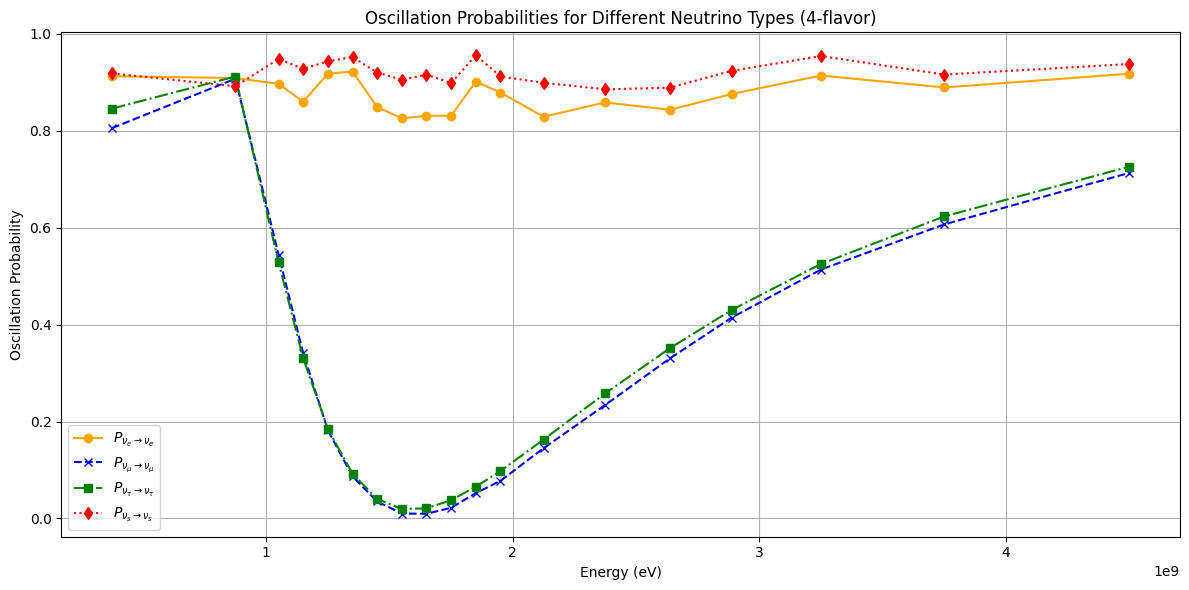

In [13]:
# Compute probabilities for all neutrino types
def compute_all_flavor_probabilities(baseline, energy_values):
    Prob_e, Prob_mu, Prob_tau, Prob_s = [], [], [], []
    for E in energy_values:
        H_vacuum = hamiltonian_4nu_vacuum(
            theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E
        )
        H_matter = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
        H_t = -1j * H_matter * baseline * CONV_KM_TO_INV_EV
        S = expm(H_t)  # Evolution operator

        # Survival and transition probabilities
        Prob_e.append(np.abs(S[0, 0])**2)  # \nu_e -> \nu_e
        Prob_mu.append(np.abs(S[1, 1])**2)  # \nu_\mu -> \nu_\mu
        Prob_tau.append(np.abs(S[2, 2])**2)  # \nu_\tau -> \nu_\tau
        Prob_s.append(np.abs(S[3, 3])**2)  # \nu_s -> \nu_s

    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau), np.array(Prob_s)

# Compute probabilities for all neutrino types at the far detector
Prob_e_far, Prob_mu_far, Prob_tau_far, Prob_s_far = compute_all_flavor_probabilities(Length_far, bin_centers)

# Plotting
plt.figure(figsize=(12, 6))

# Plot probabilities
plt.plot(bin_centers, Prob_e_far, label=r"$P_{\nu_e \rightarrow \nu_e}$", linestyle='-', marker='o', color='orange')
plt.plot(bin_centers, Prob_mu_far, label=r"$P_{\nu_\mu \rightarrow \nu_\mu}$", linestyle='--', marker='x', color='blue')
plt.plot(bin_centers, Prob_tau_far, label=r"$P_{\nu_\tau \rightarrow \nu_\tau}$", linestyle='-.', marker='s', color='green')
plt.plot(bin_centers, Prob_s_far, label=r"$P_{\nu_s \rightarrow \nu_s}$", linestyle=':', marker='d', color='red')

# Configure plot
plt.xlabel("Energy (eV)")
plt.ylabel("Oscillation Probability")
plt.title("Oscillation Probabilities for Different Neutrino Types (4-flavor)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
